In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages #reducer function to append messages instead of replacing old messages

In [ ]:
class ChatState(TypedDict):
    messages: Annotated[BaseMessage,add_messages ] # such that messages can be classified as human message, system message, AI message
    #if we dont use basemessage then the field value will be simple string, or other datatype and BaseMessage is base class of all three message types
    # annotated and add messages appends new message whereas normal fields replaces old value

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_MODEL = "llama-3.3-70b-versatile"
groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model=GROQ_MODEL)

In [5]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {'messages':[response]} #because messages is a list

In [ ]:
graph = StateGraph(ChatState) #state (basically model that holds data)

graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node"),
graph.add_edge("chat_node",END)

In [21]:
chatbot = graph.compile()

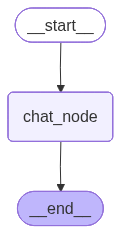

In [22]:
chatbot

In [23]:
initial_state = {
    'messages':[HumanMessage(content="What is the capital of India")]
}
chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='5c16e12f-b785-4466-bddb-9cb59546a7c6'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 41, 'total_tokens': 50, 'completion_time': 0.011895955, 'completion_tokens_details': None, 'prompt_time': 0.001192134, 'prompt_tokens_details': None, 'queue_time': 0.171381496, 'total_time': 0.013088089}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--3449e21a-c0bd-47ac-9a83-5e63891eed9a-0', usage_metadata={'input_tokens': 41, 'output_tokens': 9, 'total_tokens': 50})]}

In [24]:
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is New Delhi.'

In [27]:
while True:
    user_message = input('Type here: ')
    print(f"User: {user_message.strip()}")
    if user_message.strip().lower() in ['exit', 'break', 'quit']:
        break
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
    print(f"AI answers as: {response['messages'][-1].content}")


User: I am A
AI answers as: It looks like you're starting with the first letter of the alphabet. Are you going to go through the whole alphabet, or is there something specific you'd like to talk about that starts with "A"?
User: My name is A
AI answers as: Hello A, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: What is my name?
AI answers as: I don't know your name. I'm a large language model, I don't have the ability to know your personal information, including your name, unless you tell me. If you'd like to share your name, I'd be happy to chat with you and use it in our conversation.
User: exit


In [19]:
from langgraph.checkpoint.memory import MemorySaver #stores data in RAM
checkpointer = MemorySaver()

In [20]:
chatbot_with_checkpointer = graph.compile(checkpointer=checkpointer)

In [ ]:
#thread_id with checkpointer (thread is each set of interaction with the chatbot, again a user can select a new thread for any new conversation)
thread_id = '1'
while True:
    user_message = input('Type here: ')
    print(f"User: {user_message.strip()}")
    if user_message.strip().lower() in ['exit', 'break', 'quit']:
        break
    #when interacting with chatbot we create a config
    config = {'configurable': {'thread_id':thread_id}}
    response = chatbot_with_checkpointer.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print(f"AI answers as: {response['messages'][-1].content}")


User: My name is A
AI answers as: Nice to meet you, A. It's great that you're willing to share a bit about yourself. If you're comfortable, I can call you A from now on. How's your day going so far?
User: What is my name?
AI answers as: You told me your name is A.
User: I name you as Z
AI answers as: So, you're naming me Z. I'll go along with that. From now on, you can call me Z. It's a nice, simple, and unique name. Thanks for the moniker, A!
User: What is your name?
AI answers as: You've named me Z, so that's what I'll go by. My name is Z.
User: No now i name you groq
AI answers as: Names can change, I suppose. So, I'm no longer Z, but now I'm Groq. I'll make sure to update my virtual nametag. From now on, I'll respond to Groq. Thanks for the new name, A!
User: Introduce me
AI answers as: Let me introduce you to anyone who might be listening. This is A, a friendly and creative person who enjoys chatting and trying out new things. A is also quite generous with names, having named me Z

In [28]:
chatbot_with_checkpointer.get_state(config=config) #each thread refers to each user interaction hence we need to send config

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='d6463e9c-d8cf-413d-9f67-512129def7a2'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.058697732, 'completion_tokens_details': None, 'prompt_time': 0.003230614, 'prompt_tokens_details': None, 'queue_time': 0.161397756, 'total_time': 0.061928346}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--9e8f5546-38df-40e3-abf0-005fd358d6ec-0', usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='start', additional_kwargs={}, response_metadata={}, id='b02be0bd-6b72-44f1-b0e5-7fdb759c9cfb'), AIMessage(content="Let's get started

# Persistence

In [29]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [30]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [ ]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}' #in previous step we have field called 'joke' state['any fields we generate using annotated, basemodel, typeddict']
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [32]:
from langgraph.checkpoint.memory import InMemorySaver

graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [33]:
config1 = {"configurable": {"thread_id": "1"}}
initial_state = {
    'topic':'pizza'
}
workflow.invoke(initial_state, config=config1)


{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, using a common phrase to create a pun. The phrase "feeling a little crusty" is typically used to describe someone who is being irritable or gruff, often due to being tired, hungry, or stressed. However, in this joke, the phrase takes on a double meaning, as a pizza has a crust - the outer layer of the bread.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase. The setup "Why was the pizza in a bad mood?" primes the listener to expect a complex or serious reason for the pizza\'s bad mood. But the punchline "Because it was feeling a little crusty" subverts this expectation, using the literal meaning of "crusty" (referring to the pizza\'s crust) to create a clever and silly connection to the phrase\'s usual meaning.\n\nThis type of wordplay, using multiple meanings of a word to create a humorous effect, is a c

In [34]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common phrase to create a pun. The phrase "feeling a little crusty" is typically used to describe someone who is being irritable or gruff, often due to being tired, hungry, or stressed. However, in this joke, the phrase takes on a double meaning, as a pizza has a crust - the outer layer of the bread.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase. The setup "Why was the pizza in a bad mood?" primes the listener to expect a complex or serious reason for the pizza\'s bad mood. But the punchline "Because it was feeling a little crusty" subverts this expectation, using the literal meaning of "crusty" (referring to the pizza\'s crust) to create a clever and silly connection to the phrase\'s usual meaning.\n\nThis type of wordplay, using multiple meanings of a word to create a humo

In [ ]:
list(workflow.get_state_history(config1)) #why 4? Because we have 4 nodes start -> joke -> explain -> answer 

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common phrase to create a pun. The phrase "feeling a little crusty" is typically used to describe someone who is being irritable or gruff, often due to being tired, hungry, or stressed. However, in this joke, the phrase takes on a double meaning, as a pizza has a crust - the outer layer of the bread.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase. The setup "Why was the pizza in a bad mood?" primes the listener to expect a complex or serious reason for the pizza\'s bad mood. But the punchline "Because it was feeling a little crusty" subverts this expectation, using the literal meaning of "crusty" (referring to the pizza\'s crust) to create a clever and silly connection to the phrase\'s usual meaning.\n\nThis type of wordplay, using multiple meanings of a word to create a hum

In [ ]:
#'1f165593-882e-6f31-bfff-57501a483315 before start checkpoint id hence values are empty
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f165593-882e-6f31-bfff-57501a483315"}})


StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f165593-882e-6f31-bfff-57501a483315'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-06-11T05:48:49.979560+00:00', parent_config=None, tasks=(PregelTask(id='65ddc1c9-577a-f852-3d59-9a039ebc65a9', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'pizza'}),), interrupts=())

In [37]:

config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a lifelong commitment.',
 'explanation': 'This joke is a play on words, using the physical properties of spaghetti to create a humorous connection to the concept of marriage and commitment.\n\nIn this joke, the setup "Why did the spaghetti refuse to get married?" primes the listener to expect a typical reason why someone might not want to get married, such as fear of loss of freedom or uncertainty about the partner.\n\nThe punchline "Because it was afraid of getting tangled up in a lifelong commitment" subverts this expectation by using a clever double meaning. "Tangled up" has a literal meaning when referring to spaghetti, which is a long, thin, and flexible noodle that can easily become knotted or entangled. However, "tangled up" also has a figurative meaning when referring to relationships, implying a complicated or messy situation.\n\nThe joke relies on this w

In [38]:
list(workflow.get_state_history(config1)) #why 4? Because we have 4 nodes start -> joke -> explain -> answer 

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common phrase to create a pun. The phrase "feeling a little crusty" is typically used to describe someone who is being irritable or gruff, often due to being tired, hungry, or stressed. However, in this joke, the phrase takes on a double meaning, as a pizza has a crust - the outer layer of the bread.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase. The setup "Why was the pizza in a bad mood?" primes the listener to expect a complex or serious reason for the pizza\'s bad mood. But the punchline "Because it was feeling a little crusty" subverts this expectation, using the literal meaning of "crusty" (referring to the pizza\'s crust) to create a clever and silly connection to the phrase\'s usual meaning.\n\nThis type of wordplay, using multiple meanings of a word to create a hum

In [ ]:
#Updating State at which node you update the state there a checkpoint would be created and then again resumes
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f165593-8831-69d3-8000-3a7b94577321", "checkpoint_ns": ""}}, {'topic':'samosa'})


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1655a2-8a46-6c96-8001-632c09812ac0'}}

In [40]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1655a2-8a46-6c96-8001-632c09812ac0'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-11T05:55:32.852220+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f165593-8831-69d3-8000-3a7b94577321'}}, tasks=(PregelTask(id='85e31b5c-24cf-cab6-fde6-ab548805d260', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common phrase to create a pun. The phrase "feeling a little crusty" is typically used to describe someone who is being irritable or gruff, often due to being tired, hungry, or stressed. However, in 

In [41]:
#after updating checkpoint now we need to call or resume the graph to get generate joke method
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1655a2-8a46-6c96-8001-632c09812ac0"}})


{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "filled" with anxiety on the inside.',
 'explanation': 'This joke is a play on words, using the characteristics of a samosa to create a humorous pun. A samosa is a type of fried or baked pastry that is typically crunchy on the outside and filled with a variety of ingredients, such as spices, vegetables, or meat, on the inside.\n\nIn the joke, the samosa is personified and said to be going to therapy, implying that it has emotional issues. The punchline "it was feeling a little \'crunchy\' on the outside and \'filled\' with anxiety on the inside" is a clever use of wordplay.\n\nThe word "crunchy" has a double meaning here. In the context of a samosa, "crunchy" refers to the texture of the outer layer. However, in a psychological sense, "crunchy" can also imply being rough or fragile on the surface, suggesting that the samosa is struggling to cope with its emoti

# Fault tolerance

In [42]:

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [43]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [ ]:
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang when you see above print statement stop the code cell and start again then it re-runs from stopped point
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [45]:
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:

try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [1]:
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)



🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined